In [1]:
import io
import json
import string
import tempfile
import textwrap

import beaker
import faceted
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import wandb
import xarray as xr

from typing import Literal

import plotting

In [2]:
DETERMINISTIC_BY_SAMPLE = {
    ("SHiELD-SOM", -1): {
        0: "01KJ6HZDETE769G6XCXYVRHF3E",
        1: "01KJ6JE9QJ1TFQ0JY4061E5ES9",
    },
    ("ACE2-SOM", 3): {
        0: "01KHYVKSCN5RQY58ZHGP3NB1DY",
        1: "01KHYVKFGVPG945Q8WNQVW1HK1",
    },
}
STOCHASTIC = {
    # ("no-random-co2 non-energy-conserving", 0): "01KHW2F4QTR500B22XVBGREQ0M",
    # ("no-random-co2 non-energy-conserving", 1): "01KHW2ETWE30EAHPXRF71MXTG3",
    # ("no-random-co2 energy-conserving", 0): "01KHW2EH20KTKS4NQCR2SSXJ0S",
    # ("no-random-co2 energy-conserving", 1): "01KHW6WDRCTMRSZ8SBR2QGGSQS",
    # ("full non-energy-conserving", 0): "01KHW2DXEWW7AF909BGCNWHM9K",
    # ("full non-energy-conserving", 1): "01KHZWZYM3Y4R65RGF3NE76V4G",
    ("full energy-conserving", 0): "01KHZX09C3WC1Z2R0Z0A0MHH7S",
    # ("full energy-conserving", 1): "01KHZX0K5TMNZE9AD4H3DD6XN4",
}

In [3]:
COLORS = {
    "SHiELD-SOM": "k",
    "ACE2-SOM": "C3",
    "no-random-co2 non-energy-conserving": "C1",
    "no-random-co2 energy-conserving": "C2",
    "full non-energy-conserving": "C5",
    "full energy-conserving": "C4",
}

In [4]:
ANNUAL_DIAGNOSTICS = "main/annual_diagnostics.nc"


def open_beaker_dataset(dataset_id: str) -> xr.Dataset:
    """Given a beaker dataset ID and path within dataset, return an xarray
    dataset.

    Note: dataset must fit in memory. Requires h5netcdf backend.  Adapted from
    ace2-paper repo.
    """
    client = beaker.Beaker.from_env()
    file = client.dataset.get_file(dataset_id, ANNUAL_DIAGNOSTICS)
    ds = xr.open_dataset(io.BytesIO(file), engine="h5netcdf").load()
    if "source" in ds.dims:
        ds = ds.sel(source="target").drop_vars("source")
    return ds


def open_datasets_by_sample(dataset_ids):
    datasets = {}
    for case, beaker_datasets in dataset_ids.items():
        samples = {}
        for sample, dataset_id in beaker_datasets.items():
            samples[sample] = open_beaker_dataset(dataset_id)
        datasets[case] = xr.concat(samples.values(), dim="sample").assign_coords(sample=list(samples.keys()))
    index = pd.MultiIndex.from_tuples(datasets.keys(), names=["configuration", "seed"])
    return xr.concat(datasets.values(), dim="case").assign_coords(case=index)


def open_datasets(dataset_ids):
    datasets = {}
    for case, dataset_id in dataset_ids.items():
        datasets[case] = open_beaker_dataset(dataset_id)
    index = pd.MultiIndex.from_tuples(datasets.keys(), names=["configuration", "seed"])
    return xr.concat(datasets.values(), dim="case").assign_coords(case=index)

In [5]:
deterministic = open_datasets_by_sample(DETERMINISTIC_BY_SAMPLE)
stochastic = open_datasets(STOCHASTIC)
ds = xr.concat([deterministic, stochastic], dim="case")

/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/site-packages/beaker/util.py:25: RuntimeWarning: Found unknown field 'budget: 01HPM52AQCRXMD5BPZAMJG3TDZ' for data model 'Workspace'. This may be a newly added field that hasn't been defined in beaker-py yet. Please submit an issue report about this here:
https://github.com/allenai/beaker-py/issues/new?assignees=&labels=bug&template=bug_report.yml
  warnings.warn(
/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/site-packages/beaker/util.py:25: RuntimeWarning: Found unknown field 'budget: 01HPM52AQCRXMD5BPZAMJG3TDZ' for data model 'Dataset'. This may be a newly added field that hasn't been defined in beaker-py yet. Please submit an issue report about this here:
https://github.com/allenai/beaker-py/issues/new?assignees=&labels=bug&template=bug_report.yml
  warnings.warn(


Output()

Output()

Output()

Output()

/tmp/ipykernel_6239/3697986650.py:27: FutureWarning: the `pandas.MultiIndex` object(s) passed as 'case' coordinate(s) or data variable(s) will no longer be implicitly promoted and wrapped into multiple indexed coordinates in the future (i.e., one coordinate for each multi-index level + one dimension coordinate). If you want to keep this behavior, you need to first wrap it explicitly using `mindex_coords = xarray.Coordinates.from_pandas_multiindex(mindex_obj, 'dim')` and pass it as coordinates, e.g., `xarray.Dataset(coords=mindex_coords)`, `dataset.assign_coords(mindex_coords)` or `dataarray.assign_coords(mindex_coords)`.
  return xr.concat(datasets.values(), dim="case").assign_coords(case=index)


Output()

/tmp/ipykernel_6239/3697986650.py:35: FutureWarning: the `pandas.MultiIndex` object(s) passed as 'case' coordinate(s) or data variable(s) will no longer be implicitly promoted and wrapped into multiple indexed coordinates in the future (i.e., one coordinate for each multi-index level + one dimension coordinate). If you want to keep this behavior, you need to first wrap it explicitly using `mindex_coords = xarray.Coordinates.from_pandas_multiindex(mindex_obj, 'dim')` and pass it as coordinates, e.g., `xarray.Dataset(coords=mindex_coords)`, `dataset.assign_coords(mindex_coords)` or `dataarray.assign_coords(mindex_coords)`.
  return xr.concat(datasets.values(), dim="case").assign_coords(case=index)


In [6]:
REFERENCE = "SHiELD-SOM"
BASELINE = "ACE2-SOM"
UPDATED = "full energy-conserving"

LABELS = {
    "surface_temperature": "Global annual mean T$_s$ [K]",
    "PRATEsfc": "Global annual mean\nprecipitation [mm/day]",
    "air_temperature_0": "Global annual mean T$_0$ [K]",
    "specific_total_water_0": "Global annual mean q$_0$ [kg/kg]"
}

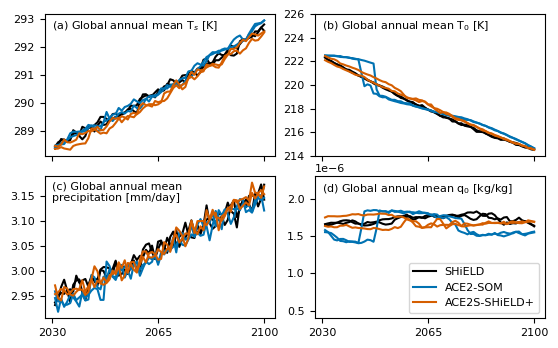

In [7]:
plotting.configure_style()

SECONDS_PER_DAY = 86400

fig, axes = faceted.faceted(
    2,
    2,
    width=5.5,
    aspect=0.618,
    internal_pad=(0.4, 0.2),
    sharey=False,
    left_pad=0.4,
    top_pad=0.1,
    right_pad=0.1,
    sharex=False
)

ax1, ax2, ax3, ax4 = axes

for ax, variable, letter in zip(axes, ["surface_temperature", "air_temperature_0", "PRATEsfc", "specific_total_water_0"], string.ascii_lowercase):
    if variable == "PRATEsfc":
        scale_factor = SECONDS_PER_DAY
    else:
        scale_factor = 1
    (scale_factor * ds.sel(case=REFERENCE)[variable]).plot(ax=ax, color=COLORS["SHiELD-SOM"], hue="sample", add_legend=False)
    (scale_factor * ds.sel(case=BASELINE)[variable]).plot(ax=ax, color=COLORS["ACE2-SOM"], hue="sample", add_legend=False)
    (scale_factor * ds.sel(case=UPDATED)[variable]).plot(ax=ax, color=COLORS["full energy-conserving"], hue="sample", add_legend=False)

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")
    ax.set_xticks([2030, 2065, 2100])

    ax.annotate(
        f"({letter}) {LABELS[variable]}", 
        xy=(0.02, 0.98), 
        xytext=(2, -2), 
        va="top", 
        xycoords="axes fraction",
        textcoords="offset points",
        bbox=dict(facecolor="w", edgecolor="none", boxstyle="round", alpha=0.75)
    )

    if variable == "specific_total_water_0":
        # Create custom legend with just three line handles
        handles = []
        labels = []
        for sample, color, label in zip(
            [REFERENCE, BASELINE, UPDATED],
            ["k", "C3", "C4"],
            ["SHiELD", "ACE2-SOM", "ACE2S-SHiELD+"]
        ):
            h, = ax.plot([], [], color=color, label=label)
            handles.append(h)
            labels.append(label)
        ax.legend(handles, labels, loc="lower right")

ax2.set_ylim([214, 226])
ax4.set_ylim([0.4e-6, 2.3e-6])

ax1.set_xticklabels([])
ax2.set_xticklabels([])

fig.patch.set_alpha(0.0)
fig.savefig("figure-04.png", dpi=300)
fig.savefig("figure-04.pdf")